<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_55_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Keras 소개

## 1. 가장 표준적인 흐름: Sequential + compile/fit/evaluate
- compile() + fit()만으로 끝나는 가장 기본적인 지도학습

In [4]:
import keras
from keras import layers
import matplotlib.pyplot as plt

In [ ]:

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=5, validation_split=0.2)
model.evaluate(x_test, y_test)

## 2. 과적합 다루기: Dropout + EarlyStopping
-  epochs=50을 줘도 val_loss가 3 epoch 연속 안 좋아지면 알아서 멈추고, 가장 좋았던 가중치로 복원한다.
- callbacks라는 개념(학습 중간에 개입하는 훅)을 처음 소개.
- history.history로 train/val loss 곡선을 그려서 "Dropout 있을 때/없을 때"를 비교해 보기 바람.

In [1]:
import keras
from keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),          # 학습 때만 일부 뉴런을 끔
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    x_train, y_train, epochs=50, validation_split=0.2,
    callbacks=[early_stop],
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8039 - loss: 0.5479 - val_accuracy: 0.8519 - val_loss: 0.4145
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8495 - loss: 0.4133 - val_accuracy: 0.8558 - val_loss: 0.3902
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8612 - loss: 0.3793 - val_accuracy: 0.8727 - val_loss: 0.3492
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8673 - loss: 0.3569 - val_accuracy: 0.8469 - val_loss: 0.4099
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8740 - loss: 0.3407 - val_accuracy: 0.8717 - val_loss: 0.3564
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8794 - loss: 0.3268 - val_accuracy: 0.8820 - val_loss: 0.3273
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8820 - loss: 0.3148 - val_accuracy: 0.8848 - val_loss: 0.3269
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8843 - loss: 0.3085 - 

In [10]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

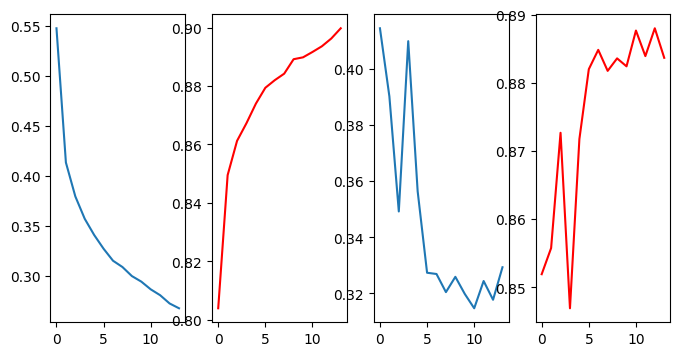

In [8]:
plt.figure(figsize=(8,4))
plt.subplot(1,4,1)
plt.plot(history.history['loss'], label='loss')
plt.subplot(1,4,2)
plt.plot(history.history['accuracy'], label='accuracy', c='r')
plt.subplot(1,4,3)
plt.plot(history.history['val_loss'], label='loss')
plt.subplot(1,4,4)
plt.plot(history.history['val_accuracy'], label='accuracy', c='r')

plt.show()

## 3. Functional API: Sequential이 못 하는 구조
- 입력이 2개, 혹은 중간에 여러 갈래로 갈라졌다 합쳐지는 구조는 Sequential(한 줄로만 쌓는 구조)로는 표현이 안 된다.
- "레이어들이 선형으로만 이어지지 않을 때 Functional API가 필요해진다.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 28, 28)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     50,240 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta (InputLayer)   │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 69)        │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ meta[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,240 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │        330 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,810 (206.29 KB)

 Trainable params: 52,810 (206.29 KB)

 Non-trainable params: 0 (0.00 B)

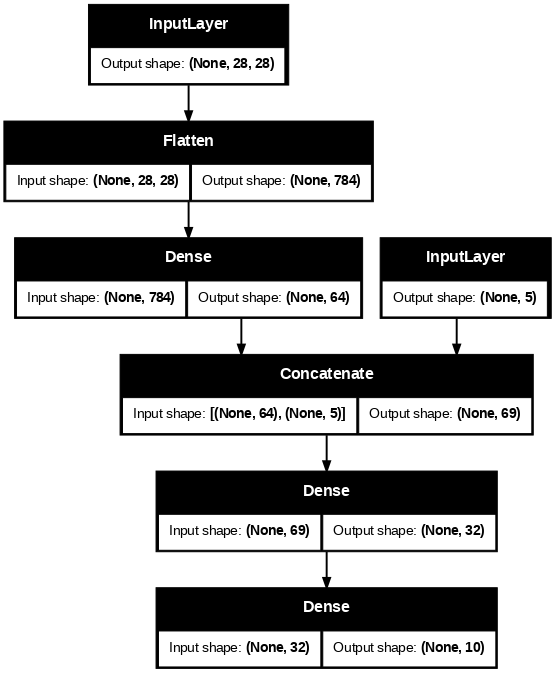

In [12]:
# 두 종류의 입력(예: 이미지 + 수치형 메타데이터)을 합치는 구조
image_input = layers.Input(shape=(28, 28), name="image")
meta_input = layers.Input(shape=(5,), name="meta")

x = layers.Flatten()(image_input)
x = layers.Dense(64, activation="relu")(x)

merged = layers.Concatenate()([x, meta_input])
merged = layers.Dense(32, activation="relu")(merged)
output = layers.Dense(10, activation="softmax")(merged)

model = keras.Model(inputs=[image_input, meta_input], outputs=output)
model.summary()

keras.utils.plot_model(model, "my_model.png", show_shapes=True, dpi=70)

## 4. Custom Layer: Dense를 직접 재구현하기

- keras.layer.Dense() 층이 하는 일 중 가장 핵심적인 계산 부분만 그대로(정확하게) 구현한 예제. (Dense 전체 기능을 다 만든 게 아님)
- add_weight(): keras.layers.Layer가 기본으로 제공하는 메서드로,"이 레이어가 학습 중 계속 갖고 있을 숫자(가중치)를 하나 만들어달라"고 요청하는 함수.
- build(self, input_shape): 가중치를 실제로 만드는 곳. 딱 한 번, 첫 입력이 들어오는 순간에 자동으로 호출된다. (즉, build()는 실제 입력이 들어와서 input_shape을 볼 수 있게 된 그 순간 호출되므로, 그때 비로소 W, b를 만들 수 있다.)
- call(self, inputs): 입력이 들어왔을 때 실제로 어떤 계산을 할지"를 적는 곳. build()가 만들어둔 W, b를 가지고 매번(매 배치, 매 호출마다) 실행된다.

In [15]:
class MyDense(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units   # output_dim

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.W = self.add_weight(
            shape=(input_dim, self.units),   # 만들 텐서의 모양
            initializer="glorot_uniform",    # 처음
            trainable=True,                  # 학습(gradient 업데이트) 대상인지
            name="W",                        # 이름 (저장/디버깅용, 선택)
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="b",
        )

    def call(self, inputs):
        return keras.ops.matmul(inputs, self.W) + self.b


# 사용 예 — keras.layers.Dense와 완전히 똑같이 동작함
model = keras.Sequential([
    layers.Input(shape=(3,)),
    MyDense(2),   # keras.layers.Dense(2)와 결과가 동일
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_dense_2 (MyDense)            │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Custom Model: Custom Model: Gradient Clipping 하나만 추가
- call(): train_step()이 실행될 때마다 그 안에서 호출된다.
- train_step(): model.fit(...)을 부르면, 그 내부에서 매 배치마다 우리가 정의한 train_step()이 자동으로 호출된다.
- 흐름도
```
- fit() 호출
 └─ (배치마다 반복)
     └─ train_step() 실행
         └─ self(x, training=True) 실행
             └─ __call__() 실행
                 ├─ (최초 1회만) build() 실행 → 가중치 생성
                 └─ (매번) call() 실행 → 실제 순전파 계산
```

In [22]:
import keras
from keras import layers
import tensorflow as tf

# ==========================================
# 1. 데이터 준비
# ==========================================
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==========================================
# 2. Custom Model — __init__ / call() / train_step() 모두 명시
# ==========================================
class ClippedModel(keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # 이 모델이 갖고 있는 부품(하위 레이어)들을 여기서 선언
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(128, activation="relu")
        self.dense2 = layers.Dense(10, activation="softmax")

    def call(self, inputs):
        # 부품들을 어떤 순서로 연결해서 계산할지
        x = self.flatten(inputs)
        x = self.dense1(x)
        return self.dense2(x)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)                     # <- 여기서 __call__() → call() 실행됨
            loss = self.compute_loss(y=y, y_pred=y_pred)        # compile(loss=...)로 지정한 손실 그대로 사용

        grads = tape.gradient(loss, self.trainable_weights)
        grads = [keras.ops.clip(g, -1.0, 1.0) for g in grads]   # <- 유일한 커스텀 로직
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)           # loss 트래커는 손실값 하나만
            else:
                metric.update_state(y, y_pred)      # 나머지(accuracy 등)는 (y, y_pred)

        return {m.name: m.result() for m in self.metrics}

# ==========================================
# 3. 모델 생성 및 컴파일
# ==========================================
model = ClippedModel(name="clipped_model")
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ==========================================
# 4. 학습 & 평가
# ==========================================
model.build(input_shape=(None, 28, 28))   # subclass 모델이라 build를 미리 해두면 summary()도 바로 가능
model.summary()

history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)
model.evaluate(x_test, y_test)

Model: "clipped_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8201 - loss: 0.5177 - val_accuracy: 0.8553 - val_loss: 0.4073
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8585 - loss: 0.3927 - val_accuracy: 0.8662 - val_loss: 0.3782
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8729 - loss: 0.3516 - val_accuracy: 0.8435 - val_loss: 0.4171
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8819 - loss: 0.3231 - val_accuracy: 0.8751 - val_loss: 0.3474
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8888 - loss: 0.3036 - val_accuracy: 0.8813 - val_loss: 0.3378
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8729 - loss: 0.3641


[0.36405736207962036, 0.8729000091552734]